# 03 Antall Samtaler (Poisson)

Formål:
- Trene Poisson-modell for `antall_samtaler`
- Sammenligne mot enkel baseline med kryssvalidering
- Lage marginaleffekt-plott for valgte variabler

In [10]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance

sns.set_theme(style="whitegrid")

project_root = Path.cwd().resolve().parent.parent
code_dir = project_root / "code"
if str(code_dir) not in sys.path:
    sys.path.append(str(code_dir))

from utils.data_load import load_raw_data
from utils.data_prep import data_prep
from utils.models import fit_count_model, cross_validate_count_model, DEFAULT_CATEGORICAL_FEATURES

In [11]:
# Konfig
TARGET = "antall_samtaler"
K_FOLDS = 10
RANDOM_STATE = 42

# Stabiliserer Poisson-fit (reg + flere iterasjoner)
POISSON_ALPHA = 0.3
POISSON_MAX_ITER = 10000

# CV-basert feature selection
FEATURE_SELECTION_MAX_STEPS = 8
FEATURE_SELECTION_MIN_IMPROVEMENT = 0.01

NEWSLETTER_CSV = project_root / "data" / "newsletter_sendouts.csv"
WEATHER_CSV = project_root / "data" / "oslo_weather.csv"

# ---- KANDIDATFEATURES (feature selection velger fra disse) ----
calendar_features = [
    "maaned",  "ukedag", "dag_i_maaned",
    "er_helg", "helligdag", "er_helligdag", "er_dag_foer_helligdag", "er_dag_etter_helligdag",
]
weather_features = ["tempavvik_fra_mndsnitt", "nedbør"]

# Bruk enten komponenter ELLER totaler for aa unngaa perfekt multikollinearitet.
business_features = [
    "antall_nye_kunder_b30_tot",
    "antall_hf_b30_tot",
    "stddev_premieendring_b30_for",
    "snitt_premieendring_b30_for",
]

extra_features = ["nyhetsbrev_b7"]

candidate_features = calendar_features + weather_features + business_features + extra_features

In [12]:
# Last data og bygg analyseklar dataframe

df_inngang, df_info, df_weather = load_raw_data(
    session=None,
    weather_path=WEATHER_CSV,
)

df = data_prep(
    df_inngang=df_inngang,
    df_info=df_info,
    df_weather=df_weather,
    cols_to_remove=None,
    newsletter_dates_csv=str(NEWSLETTER_CSV),
)

print("Prepared shape:", df.shape)
print("Dato fra/til:", df["ankomst_dato"].min(), "->", df["ankomst_dato"].max())
print("Target NA:", int(df[TARGET].isna().sum()))

Prepared shape: (499, 132)
Dato fra/til: 2024-06-03 -> 2026-06-02
Target NA: 0


In [13]:
# CV-basert feature selection (forward selection)
missing_candidates = [col for col in candidate_features if col not in df.columns]
available_candidates = [col for col in candidate_features if col in df.columns and col != TARGET]

print("Antall kandidatfeatures:", len(available_candidates))
if missing_candidates:
    print("Kandidatfeatures som mangler og hoppes over:", missing_candidates)

if len(available_candidates) == 0:
    raise ValueError("Ingen gyldige kandidatfeatures funnet i df.")

remaining = available_candidates.copy()
selected = []
history = []
best_dev_so_far = np.inf

max_steps = min(FEATURE_SELECTION_MAX_STEPS, len(remaining))

for step in range(1, max_steps + 1):
    step_rows = []

    for candidate in remaining:
        current_features = selected + [candidate]
        current_cat = [col for col in DEFAULT_CATEGORICAL_FEATURES if col in current_features]

        metrics = cross_validate_count_model(
            df=df,
            feature_cols=current_features,
            target_col=TARGET,
            categorical_features=current_cat,
            k=K_FOLDS,
            random_state=RANDOM_STATE,
            alpha=POISSON_ALPHA,
            max_iter=POISSON_MAX_ITER,
        )

        step_rows.append(
            {
                "candidate": candidate,
                "poisson_dev_mean": metrics["poisson_dev_mean"],
                "mae_mean": metrics["mae_mean"],
                "rmse_mean": metrics["rmse_mean"],
                "r2_mean": metrics["r2_mean"],
            }
        )

    step_df = pd.DataFrame(step_rows).sort_values("poisson_dev_mean", ascending=True).reset_index(drop=True)
    best_row = step_df.iloc[0]

    best_candidate = best_row["candidate"]
    best_candidate_dev = float(best_row["poisson_dev_mean"])
    improvement = (best_dev_so_far - best_candidate_dev) if np.isfinite(best_dev_so_far) else np.nan

    history.append(
        {
            "step": step,
            "added_feature": best_candidate,
            "poisson_dev_mean": best_candidate_dev,
            "mae_mean": float(best_row["mae_mean"]),
            "rmse_mean": float(best_row["rmse_mean"]),
            "r2_mean": float(best_row["r2_mean"]),
            "improvement_vs_prev": improvement,
            "selected_features": selected + [best_candidate],
        }
    )

    if np.isfinite(best_dev_so_far) and improvement < FEATURE_SELECTION_MIN_IMPROVEMENT:
        print(f"Stopper ved steg {step}: forbedring {improvement:.4f} < {FEATURE_SELECTION_MIN_IMPROVEMENT}")
        break

    selected.append(best_candidate)
    remaining.remove(best_candidate)
    best_dev_so_far = best_candidate_dev

    if len(remaining) == 0:
        break

selected_history_df = pd.DataFrame(history)
feature_cols = selected.copy()

print("\nValgte features via CV:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {col}")

selected_history_df

Antall kandidatfeatures: 15

Valgte features via CV:
01. maaned
02. stddev_premieendring_b30_for
03. antall_nye_kunder_b30_tot
04. er_dag_foer_helligdag
05. tempavvik_fra_mndsnitt
06. ukedag
07. snitt_premieendring_b30_for
08. antall_hf_b30_tot


,step,added_feature,poisson_dev_mean,mae_mean,rmse_mean,r2_mean,improvement_vs_prev,selected_features
0,1,maaned,27.557245,69.514228,89.596417,0.173265,NaN,[maaned]
1,2,stddev_premieendring_b30_for,26.145132,67.806360,87.528006,0.212443,1.412113,"[maaned, stddev_premieendring_b30_for]"
2,3,antall_nye_kunder_b30_tot,25.524639,66.342439,86.344025,0.233616,0.620494,"[maaned, stddev_premieendring_b30_for, antall_..."
3,4,er_dag_foer_helligdag,25.307570,66.083246,86.024414,0.236308,0.217068,"[maaned, stddev_premieendring_b30_for, antall_..."
4,5,tempavvik_fra_mndsnitt,25.135190,66.215691,85.843541,0.240491,0.172380,"[maaned, stddev_premieendring_b30_for, antall_..."
5,6,ukedag,24.992591,66.204676,85.714643,0.238950,0.142599,"[maaned, stddev_premieendring_b30_for, antall_..."
6,7,snitt_premieendring_b30_for,24.941625,66.113014,85.704189,0.238387,0.050966,"[maaned, stddev_premieendring_b30_for, antall_..."
7,8,antall_hf_b30_tot,24.898932,66.039826,85.636578,0.240159,0.042693,"[maaned, stddev_premieendring_b30_for, antall_..."


In [14]:
# Baseline CV (predikerer treningsgjennomsnitt)
frame = df[feature_cols + [TARGET]].dropna(subset=[TARGET]).copy()
X = frame[feature_cols]
y = frame[TARGET].astype(float)

cv = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rows = []

for train_idx, test_idx in cv.split(X):
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    pred = np.full(shape=len(test_idx), fill_value=float(y_train.mean()))
    pred_pos = np.clip(pred, 1e-9, None)

    rows.append(
        {
            "poisson_dev": mean_poisson_deviance(y_test, pred_pos),
            "mae": mean_absolute_error(y_test, pred),
            "rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
            "r2": r2_score(y_test, pred),
        }
    )

baseline_cv = pd.DataFrame(rows)
baseline_metrics = {
    "poisson_dev_mean": baseline_cv["poisson_dev"].mean(),
    "poisson_dev_std": baseline_cv["poisson_dev"].std(),
    "mae_mean": baseline_cv["mae"].mean(),
    "mae_std": baseline_cv["mae"].std(),
    "rmse_mean": baseline_cv["rmse"].mean(),
    "rmse_std": baseline_cv["rmse"].std(),
    "r2_mean": baseline_cv["r2"].mean(),
    "r2_std": baseline_cv["r2"].std(),
}

pd.Series(baseline_metrics)

poisson_dev_mean     34.798196
poisson_dev_std       5.584740
mae_mean             81.326502
mae_std               5.978773
rmse_mean           100.676819
rmse_std              7.838217
r2_mean              -0.029481
r2_std                0.030562
dtype: float64

In [15]:
# Poisson CV + endelig fit
categorical_features = [col for col in DEFAULT_CATEGORICAL_FEATURES if col in feature_cols]

poisson_metrics = cross_validate_count_model(
    df=df,
    feature_cols=feature_cols,
    target_col=TARGET,
    categorical_features=categorical_features,
    k=K_FOLDS,
    random_state=RANDOM_STATE,
    alpha=POISSON_ALPHA,
    max_iter=POISSON_MAX_ITER,
)

count_model = fit_count_model(
    df=df,
    feature_cols=feature_cols,
    target_col=TARGET,
    categorical_features=categorical_features,
    alpha=POISSON_ALPHA,
    max_iter=POISSON_MAX_ITER,
)

model_df = df[feature_cols + [TARGET, "ankomst_dato"]].dropna(subset=[TARGET]).copy()
model_df["pred_antall_samtaler"] = np.clip(count_model.predict(model_df[feature_cols]), 1e-9, None)

metrics_df = pd.DataFrame([
    {
        "model": "baseline",
        **baseline_metrics,
    },
    {
        "model": "poisson",
        **poisson_metrics,
    },
])

print(f"Poisson alpha: {POISSON_ALPHA}")
print(f"Poisson max_iter: {POISSON_MAX_ITER}")
metrics_df

Poisson alpha: 0.3
Poisson max_iter: 10000


,model,poisson_dev_mean,poisson_dev_std,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
0,baseline,34.798196,5.584740,81.326502,5.978773,100.676819,7.838217,-0.029481,0.030562
1,poisson,24.898932,5.488353,66.039826,5.207889,85.636578,7.465077,0.240159,0.168689


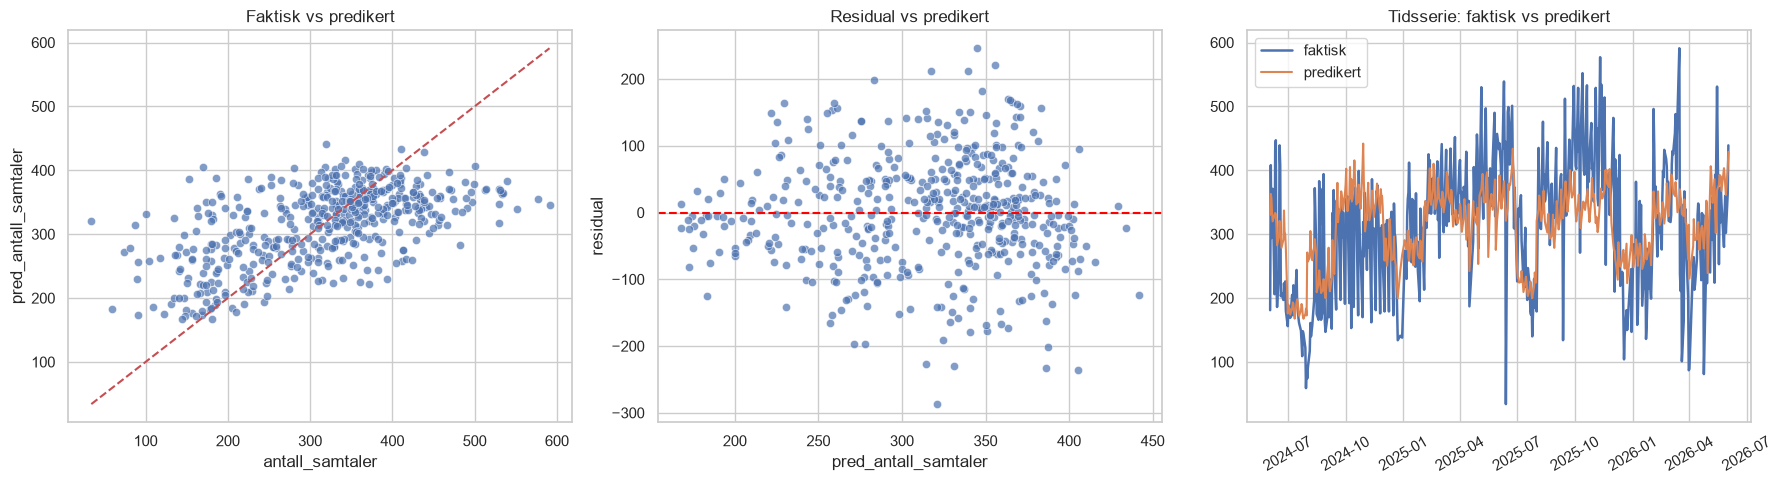

In [16]:
# Diagnostikk: faktisk vs predikert
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=model_df,
    x=TARGET,
    y="pred_antall_samtaler",
    s=35,
    alpha=0.7,
    ax=axes[0],
)
axes[0].plot([model_df[TARGET].min(), model_df[TARGET].max()], [model_df[TARGET].min(), model_df[TARGET].max()], "r--")
axes[0].set_title("Faktisk vs predikert")

residual = model_df[TARGET] - model_df["pred_antall_samtaler"]
sns.scatterplot(
    x=model_df["pred_antall_samtaler"],
    y=residual,
    s=35,
    alpha=0.7,
    ax=axes[1],
)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residual vs predikert")
axes[1].set_xlabel("pred_antall_samtaler")
axes[1].set_ylabel("residual")

plot_df = model_df.sort_values("ankomst_dato").copy()
axes[2].plot(plot_df["ankomst_dato"], plot_df[TARGET], label="faktisk", linewidth=1.8)
axes[2].plot(plot_df["ankomst_dato"], plot_df["pred_antall_samtaler"], label="predikert", linewidth=1.5)
axes[2].set_title("Tidsserie: faktisk vs predikert")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend()

plt.tight_layout()
plt.show()

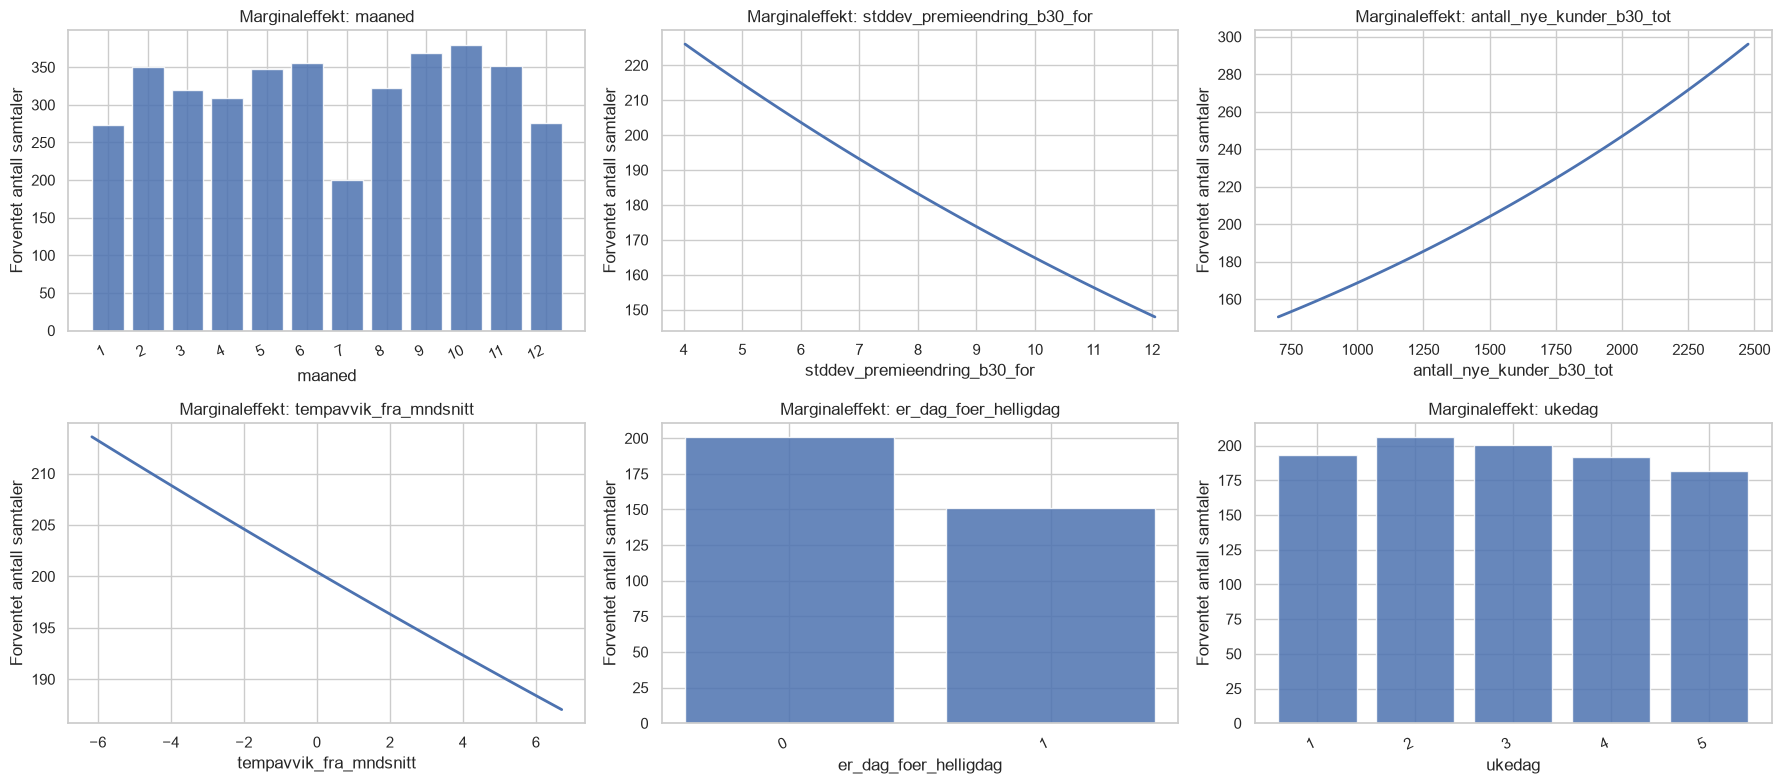

In [17]:
# Marginaleffekt-plott for valgte variabler
marginal_vars = [
    # "nyhetsbrev_b7",
    # "middeltemperatur",
    # "nedbør",
    # "antall_nye_kunder_b30_tot",
    # "antall_hf_b30_tot",
    # "ukedag",
'maaned',
'stddev_premieendring_b30_for',
'antall_nye_kunder_b30_tot',
'tempavvik_fra_mndsnitt',
'middeltemperatur',
'er_dag_foer_helligdag',
'ukedag',
'kvartal'
]
marginal_vars = [col for col in marginal_vars if col in feature_cols]

if len(marginal_vars) == 0:
    raise ValueError("Ingen marginal-vars finnes i feature_cols.")


def _typical_row(frame: pd.DataFrame, cols: list[str]) -> dict:
    row = {}
    for col in cols:
        series = frame[col]
        if pd.api.types.is_numeric_dtype(series):
            row[col] = float(series.median())
        else:
            mode = series.mode(dropna=True)
            row[col] = mode.iloc[0] if len(mode) > 0 else series.dropna().iloc[0]
    return row


base = _typical_row(model_df, feature_cols)

n = len(marginal_vars)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, var in enumerate(marginal_vars):
    ax = axes[i]
    series = model_df[var].dropna()
    is_categorical = (var in categorical_features) or (series.nunique() <= 8)

    if is_categorical:
        levels = sorted(series.unique().tolist())
        rows = []
        for level in levels:
            r = base.copy()
            r[var] = level
            rows.append(r)

        pred_df = pd.DataFrame(rows)
        pred = np.clip(count_model.predict(pred_df[feature_cols]), 1e-9, None)

        ax.bar(range(len(levels)), pred, color="#4C72B0", alpha=0.85)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels(levels, rotation=25, ha="right")
        ax.set_xlabel(var)
        ax.set_ylabel("Forventet antall samtaler")
        ax.set_title(f"Marginaleffekt: {var}")
    else:
        x_grid = np.linspace(series.quantile(0.01), series.quantile(0.99), 100)
        pred_rows = []
        for x_val in x_grid:
            r = base.copy()
            r[var] = float(x_val)
            pred_rows.append(r)

        pred_df = pd.DataFrame(pred_rows)
        pred = np.clip(count_model.predict(pred_df[feature_cols]), 1e-9, None)

        ax.plot(x_grid, pred, color="#4C72B0", linewidth=2)
        ax.set_xlabel(var)
        ax.set_ylabel("Forventet antall samtaler")
        ax.set_title(f"Marginaleffekt: {var}")

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Oppsummering
summary = pd.DataFrame(
    {
        "metric": ["poisson_dev_mean", "mae_mean", "rmse_mean", "r2_mean"],
        "baseline": [
            baseline_metrics["poisson_dev_mean"],
            baseline_metrics["mae_mean"],
            baseline_metrics["rmse_mean"],
            baseline_metrics["r2_mean"],
        ],
        "poisson": [
            poisson_metrics["poisson_dev_mean"],
            poisson_metrics["mae_mean"],
            poisson_metrics["rmse_mean"],
            poisson_metrics["r2_mean"],
        ],
    }
)

summary["best_direction"] = ["lower", "lower", "lower", "higher"]
summary["delta_poisson_minus_baseline"] = summary["poisson"] - summary["baseline"]
summary["poisson_better"] = [
    delta < 0 if direction == "lower" else delta > 0
    for delta, direction in zip(summary["delta_poisson_minus_baseline"], summary["best_direction"])
]
summary

,metric,baseline,poisson,best_direction,delta_poisson_minus_baseline,poisson_better
0,poisson_dev_mean,34.798196,24.898932,lower,-9.899264,True
1,mae_mean,81.326502,66.039826,lower,-15.286676,True
2,rmse_mean,100.676819,85.636578,lower,-15.040240,True
3,r2_mean,-0.029481,0.240159,higher,0.269640,True


## Notater

- Marginaleffekt-plottene holder alle andre variabler faste ved en typisk verdi.
- For kategoriske variabler vises predikert nivaa per kategori.
- For kontinuerlige variabler vises en prediksjonskurve mellom 1- og 99-persentil.